# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import pandas as pd

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")
interactions = pd.read_parquet("interactions.parquet")

In [3]:
display(tracks.head())
display(catalog_names.sample(5).head())
display(interactions.sample(5).head())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,id,type,name
990448,4855083,track,Sleeping
887420,669799,track,It's Alright (Baby's Coming Back)
494177,10884351,album,Нарушители пустоты
438515,8857566,album,think of me
953324,2830410,track,Дым и вода


,user_id,track_id,track_seq,started_at
957,1285658,41418309,958,2022-10-13
188,968998,37138319,189,2022-09-25
48,977525,1531474,49,2022-12-02
798,1097982,37606534,799,2022-10-23
15,1286610,63196880,16,2022-10-22


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [4]:
# Анализ идентификаторов треков
print(tracks['track_id'].dtypes)
print(tracks['track_id'].duplicated().sum()) # Не имеет дубликатов track_id
print(tracks['track_id'].isnull().sum())

int64
0
0


In [5]:
album_ids = tracks['albums'].explode()
artist_ids = tracks['artists'].explode()
genre_id = tracks['genres'].explode()

# Проверка есть ли треки с неизвестными исполнителями, альбомами, жанрами
print(album_ids.isnull().sum())
print(artist_ids.isnull().sum())
print(genre_id.isnull().sum())
# Такие треки есть

#Удаляем треки с пропусками
indices_to_drop = (album_ids[album_ids.isnull()].index
                   .union(artist_ids[artist_ids.isnull()].index)
                   .union(genre_id[genre_id.isnull()].index))
tracks = tracks.drop(index=indices_to_drop)
tracks.reset_index(drop=True, inplace=True)

# Очередная проверка есть ли треки с неизвестными исполнителями, альбомами, жанрами
album_ids = tracks['albums'].explode()
artist_ids = tracks['artists'].explode()
genre_id = tracks['genres'].explode()
print(album_ids.isnull().sum())
print(artist_ids.isnull().sum())
print(genre_id.isnull().sum())

18
15369
3687
0
0
0


In [6]:
#Проверка на пропуски
print(catalog_names.isnull().sum(axis=1).sum(), 'Пропусков в catalog_names') # Пропусков нет

# Проверка на пересечение идентификаторов
print(album_ids.isin(artist_ids).sum(), album_ids.isin(genre_id).sum(), artist_ids.isin(genre_id).sum(), 'Пересечение id у album, artist, genre') # Идентификаторы пересекаются, но у них разный type, объект можно идентифицировать по id + type

#Проверка на дупликаты
print(catalog_names.duplicated().sum(), 'Кол-во дубликтов в catalog_names') # Дублей нету

def check_object_ids(catalog_names: pd.DataFrame, type: str, ids: pd.Series):
    uniq_ids = ids.unique()
    catalog_type_ids = catalog_names.loc[catalog_names.type == type]['id'].unique()
    print(f'Для типа {type} у треков {len(uniq_ids)} уникальных id; У catalog_names {len(catalog_type_ids)}; {len(list(set(uniq_ids) - set(catalog_type_ids)))} есть id, которых по типу {type} не у каталогов')
    return list(set(uniq_ids) - set(catalog_type_ids))
    
#Проверка наличия идентификаторов в catalog_names
print((~pd.Series(album_ids.unique()).isin(catalog_names.loc[catalog_names['type'] == 'album']['id'])).sum(), 'Кол-во не хватающих id альбомов в catalog_names') # Все id альбомов есть в catalog_names
print((~pd.Series(artist_ids.unique()).isin(catalog_names.loc[catalog_names['type'] == 'artist']['id'])).sum(), 'Кол-во не хватающих id артистов в catalog_names') # Все id артистов есть в catalog_names
print((~pd.Series(genre_id.unique()).isin(catalog_names.loc[catalog_names['type'] == 'genre']['id'])).sum(), 'Кол-во не хватающих id жанров в catalog_names') # id жанров не хватает в catalog_names
print((~tracks['track_id'].isin(catalog_names.loc[catalog_names['type'] == 'track']['id'])).sum(), 'Кол-во не хватающих id треков в catalog_names') # Все id треков есть в catalog_names
check_object_ids(catalog_names, 'album', album_ids)
check_object_ids(catalog_names, 'artist', artist_ids)
no_genre_ids = check_object_ids(catalog_names, 'genre', genre_id)
print(no_genre_ids)
display(catalog_names.loc[catalog_names.id.isin(no_genre_ids) & (catalog_names.type != 'genre')])


0 Пропусков в catalog_names
64183 370 1297 Пересечение id у album, artist, genre
0 Кол-во дубликтов в catalog_names
0 Кол-во не хватающих id альбомов в catalog_names
0 Кол-во не хватающих id артистов в catalog_names
30 Кол-во не хватающих id жанров в catalog_names
0 Кол-во не хватающих id треков в catalog_names
Для типа album у треков 653563 уникальных id; У catalog_names 658724; 0 есть id, которых по типу album не у каталогов
Для типа artist у треков 152785 уникальных id; У catalog_names 153581; 0 есть id, которых по типу artist не у каталогов
Для типа genre у треков 166 уникальных id; У catalog_names 166; 30 есть id, которых по типу genre не у каталогов
[130, 131, 132, 133, 134, 135, 146, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 124, 126]


,id,type,name
49,126,album,Arma-goddamn-motherfuckin-geddon
51,132,album,LoveGame Remixes
52,133,album,Best Of
53,134,album,Specialty Profiles: Roy Milton
54,135,album,LoveGame
61,146,album,Zee Avi
62,148,album,In A Perfect World...
64,150,album,B Is For Bob
65,152,album,Trojan Lovers Collection
66,154,album,Stop!


In [7]:
mask = tracks['genres'].apply(lambda x: not set(x).isdisjoint(no_genre_ids))
tracks[mask]
#48313 треков, у которых в жанре есть id, которого нету в справочнике catalog_names


,track_id,albums,artists,genres
36,436,[36],[330],"[28, 164]"
59,594,"[54, 88, 5479, 5785124, 9198099, 9231427, 1088...",[533],"[28, 162]"
125,1025,"[94, 2325, 8757, 8986, 318695, 17004129]",[937],"[28, 162]"
126,1026,"[94, 780, 8727]",[937],"[28, 162]"
128,1028,"[94, 4865, 19666753, 19666891]",[936],"[28, 162]"
...,...,...,...,...
980753,101009893,[21261051],"[9772048, 9772047]","[47, 161]"
980781,101049628,[21272435],[5926594],"[47, 161]"
980845,101200283,[21314376],[4130480],"[47, 154]"
980886,101256806,[21331759],[5926594],"[47, 161]"


In [8]:
#Проверяем типы данных идентификаторов
display(tracks.dtypes)
display(catalog_names.dtypes)
display(interactions.dtypes)
#Можно заметить тип данных в intersactions у track_id int32, а у tracks int64 => можно скастить типы для экономии памяти и избежания переполнения int32 в случае большего значения id в tracks

track_id     int64
albums      object
artists     object
genres      object
dtype: object

id       int64
type    object
name    object
dtype: object

user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object

In [9]:
#Проверяем дубликаты и пропущенные значения
print(catalog_names.duplicated().sum(), 'Кол-во дубликатов у catalog_names', catalog_names.isnull().sum(axis=1).sum(), 'Кол-во пропущенных значений')
print(interactions.duplicated().sum(), 'Кол-во дубликатов у interactions', catalog_names.isnull().sum(axis=1).sum(), 'Кол-во пропущенных значений')


0 Кол-во дубликатов у catalog_names 0 Кол-во пропущенных значений
0 Кол-во дубликатов у interactions 0 Кол-во пропущенных значений


In [10]:
# Испрвляем оставшиеся проблемы
# Удаляем треки, у которых не сущ в catalog_names жанры есть
tracks = tracks[~mask]
del mask # Освобождаем память


In [11]:
# Меняем тип данных track_id в tracks
tracks['track_id'] = tracks['track_id'].astype('int32')

In [13]:
del indices_to_drop

In [14]:
del check_object_ids

In [12]:
# Удаляем из interactions треки, которых нет в tracks
interactions = interactions.loc[(interactions.track_id.isin(tracks.track_id))]
del no_genre_ids, album_ids, artist_ids, genre_id


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

## В ходе подготовки данных были выявлены след. проблемы: 
- типы данных для track_id у interactions и tracks различаются;
- есть треки с пропусками данных в колонках: albums, artists, genres
- есть треки, которые в genres имеют идентификаторы, которых нету в справочнике catalog_names с type = 'genre'
- в следствии проблем выше с треками в interactions есть записи, которые нужно удалить после очистки треков.

## Предпринятые шаги решения проблем:
- каст типов track_id
- удаление треков с пропусками в колонках albums, artists, genres
- удаление треков, содержащих genres, которых нет в catalog_names
- очистка interactions

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

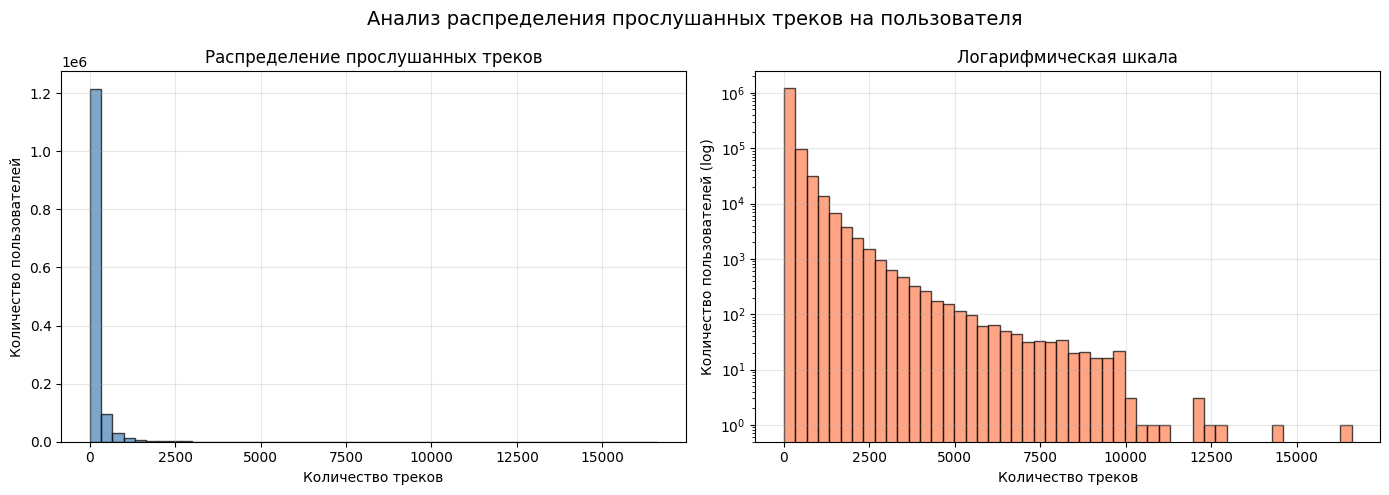

СТАТИСТИКА по прослуш трекам
Размер выборки (n): 1372042
Среднее арифметическое (μ): 156.50
Медиана (Me): 54
Мода (Mo): 11
Минимум (min): 1
Максимум (max): 16609
25-й перцентиль (Q1): 22
75-й перцентиль (Q3): 149
Межквартильный размах (IQR): 127


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Подсчет прослушанных треков на пользователя
user_counts = interactions.groupby('user_id')['track_id'].count().reset_index(name='tracks_played')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Гистограмма
axes[0].hist(user_counts['tracks_played'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Распределение прослушанных треков')
axes[0].set_xlabel('Количество треков')
axes[0].set_ylabel('Количество пользователей')
axes[0].grid(True, alpha=0.3)

# 2. Логарифмическая шкала
axes[1].hist(user_counts['tracks_played'], bins=50, edgecolor='black', alpha=0.7, color='coral', log=True)
axes[1].set_title('Логарифмическая шкала')
axes[1].set_xlabel('Количество треков')
axes[1].set_ylabel('Количество пользователей (log)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Анализ распределения прослушанных треков на пользователя', fontsize=14)
plt.tight_layout()
plt.show()

# Математическая статистика
print("="*60)
print("СТАТИСТИКА по прослуш трекам")
print("="*60)

data = user_counts['tracks_played']
stats = data.describe()

print(f"Размер выборки (n): {len(data)}")
print(f"Среднее арифметическое (μ): {stats['mean']:.2f}")
print(f"Медиана (Me): {stats['50%']:.0f}")
print(f"Мода (Mo): {data.mode().values[0]}")
print(f"Минимум (min): {stats['min']:.0f}")
print(f"Максимум (max): {stats['max']:.0f}")
print(f"25-й перцентиль (Q1): {stats['25%']:.0f}")
print(f"75-й перцентиль (Q3): {stats['75%']:.0f}")
print(f"Межквартильный размах (IQR): {stats['75%'] - stats['25%']:.0f}")

Наиболее популярные треки

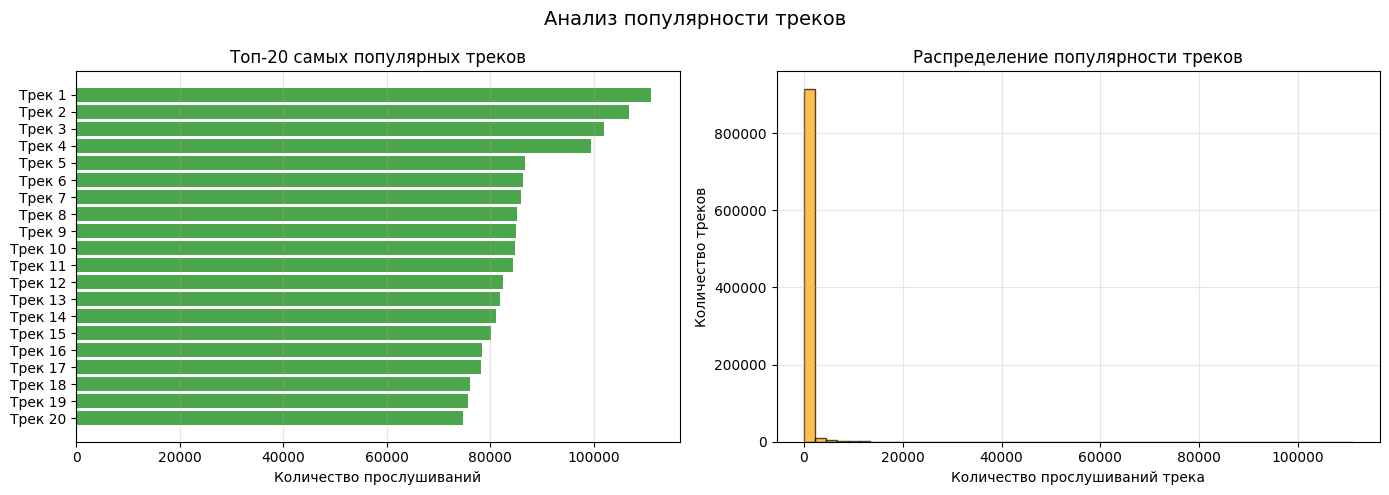

СТАТИСТИКА ПОПУЛЯРНОСТИ ТРЕКОВ
Всего треков: 932664
Всего прослушиваний: 214720738
Среднее прослушиваний на трек: 230.22
Медиана: 19
Мода: 6
Минимум: 5
Максимум: 111062
25-й перцентиль (Q1): 9
75-й перцентиль (Q3): 69

ТОП-5 САМЫХ ПОПУЛЯРНЫХ ТРЕКОВ:
Трек 53404: 111062 прослушиваний
Трек 33311009: 106921 прослушиваний
Трек 178529: 101924 прослушиваний
Трек 35505245: 99490 прослушиваний
Трек 65851540: 86670 прослушиваний

ТОП-5 НАИМЕНЕЕ ПОПУЛЯРНЫХ ТРЕКОВ (из прослушанных):
Трек 39922653: 5 прослушиваний
Трек 39924004: 5 прослушиваний
Трек 71306433: 5 прослушиваний
Трек 14626352: 5 прослушиваний
Трек 26: 5 прослушиваний


In [ ]:
# Подсчет прослушиваний каждого трека
track_popularity = interactions.groupby('track_id')['user_id'].count().reset_index()
track_popularity.columns = ['track_id', 'play_count']
track_popularity = track_popularity.sort_values('play_count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Топ-20 треков
top_20 = track_popularity.head(20)
axes[0].barh(range(len(top_20)), top_20['play_count'].values, color='green', alpha=0.7)
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels([f"Трек {i+1}" for i in range(len(top_20))])
axes[0].set_xlabel('Количество прослушиваний')
axes[0].set_title('Топ-20 самых популярных треков')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Распределение популярности
axes[1].hist(track_popularity['play_count'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Количество прослушиваний трека')
axes[1].set_ylabel('Количество треков')
axes[1].set_title('Распределение популярности треков')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Анализ популярности треков', fontsize=14)
plt.tight_layout()
plt.show()

# Математическая статистика
print("="*60)
print("СТАТИСТИКА ПОПУЛЯРНОСТИ ТРЕКОВ")
print("="*60)

data = track_popularity['play_count']
stats = data.describe()

print(f"Всего треков: {len(data)}")
print(f"Всего прослушиваний: {data.sum()}")
print(f"Среднее прослушиваний на трек: {data.mean():.2f}")
print(f"Медиана: {data.median():.0f}")
print(f"Мода: {data.mode().values[0]}")
print(f"Минимум: {data.min()}")
print(f"Максимум: {data.max()}")
print(f"25-й перцентиль (Q1): {stats['25%']:.0f}")
print(f"75-й перцентиль (Q3): {stats['75%']:.0f}")

print("\nТОП-5 САМЫХ ПОПУЛЯРНЫХ ТРЕКОВ:")
for i, row in track_popularity.head(5).iterrows():
    print(f"Трек {row['track_id']}: {row['play_count']} прослушиваний")

print("\nТОП-5 НАИМЕНЕЕ ПОПУЛЯРНЫХ ТРЕКОВ (из прослушанных):")
for i, row in track_popularity.tail(5).iterrows():
    print(f"Трек {row['track_id']}: {row['play_count']} прослушиваний")

Наиболее популярные жанры

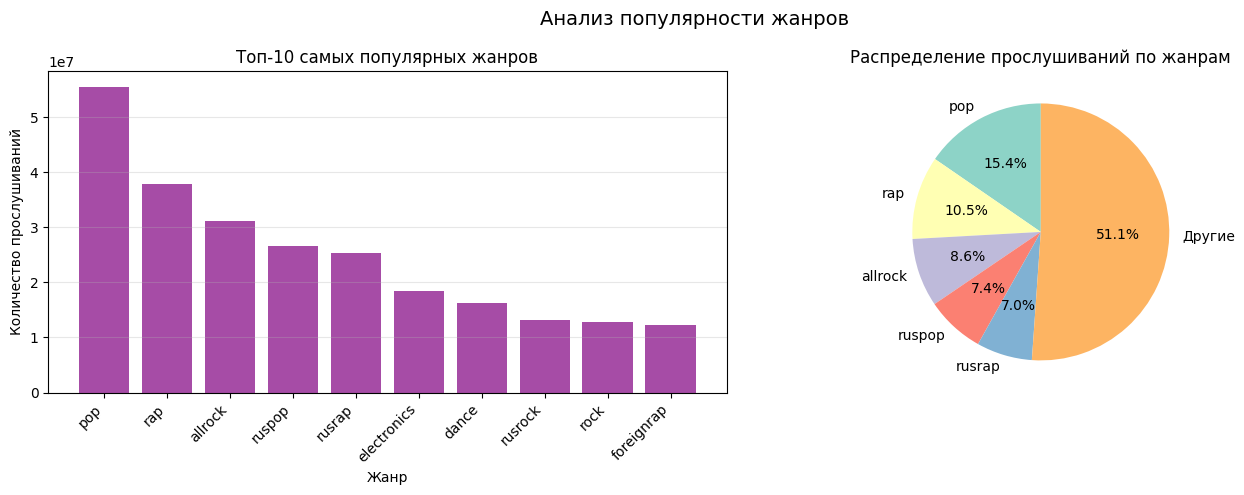

СТАТИСТИКА ПОПУЛЯРНОСТИ ЖАНРОВ
Всего жанров: 131
Всего прослушиваний: 360726341
Среднее: 2753636.19
Медиана: 228315
Мин: 20, Макс: 55551134

ТОП-5 ЖАНРОВ:
  1. pop: 55551134 (15.4%)
  2. rap: 37799684 (10.5%)
  3. allrock: 31085569 (8.6%)
  4. ruspop: 26626234 (7.4%)
  5. rusrap: 25303695 (7.0%)

КОНЦЕНТРАЦИЯ:
Топ-1: 15.4%
Топ-3: 34.5%
Топ-5: 48.9%


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

genres_dict = {}
for _, item in catalog_names.iterrows():
    if item['type'] == 'genre':
        genres_dict[item['id']] = item['name']

tracks_exploded = tracks.explode('genres')

tracks_exploded['genre_name'] = tracks_exploded['genres'].map(genres_dict)

interactions_with_genres = interactions.merge(
    tracks_exploded[['track_id', 'genre_name']], 
    on='track_id', 
    how='left'
)

interactions_with_genres = interactions_with_genres.dropna(subset=['genre_name'])

genre_popularity = interactions_with_genres.groupby('genre_name')['user_id'].count().reset_index()
genre_popularity.columns = ['genre', 'play_count']
genre_popularity = genre_popularity.sort_values('play_count', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Топ-10 жанров
top_10 = genre_popularity.head(10)
axes[0].bar(range(len(top_10)), top_10['play_count'].values, color='purple', alpha=0.7)
axes[0].set_xticks(range(len(top_10)))
axes[0].set_xticklabels(top_10['genre'], rotation=45, ha='right')
axes[0].set_xlabel('Жанр')
axes[0].set_ylabel('Количество прослушиваний')
axes[0].set_title('Топ-10 самых популярных жанров')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. Круговая диаграмма
top_5 = genre_popularity.head(5)
other_sum = genre_popularity.iloc[5:]['play_count'].sum()
pie_data = pd.concat([top_5, pd.DataFrame([{'genre': 'Другие', 'play_count': other_sum}])])

axes[1].pie(pie_data['play_count'], labels=pie_data['genre'], autopct='%1.1f%%', 
            startangle=90, colors=plt.cm.Set3(range(len(pie_data))))
axes[1].set_title('Распределение прослушиваний по жанрам')

plt.suptitle('Анализ популярности жанров', fontsize=14)
plt.tight_layout()
plt.show()

# Статистика
print("="*60)
print("СТАТИСТИКА ПОПУЛЯРНОСТИ ЖАНРОВ")
print("="*60)

data = genre_popularity['play_count']
total_plays = data.sum()

print(f"Всего жанров: {len(data)}")
print(f"Всего прослушиваний: {total_plays}")
print(f"Среднее: {data.mean():.2f}")
print(f"Медиана: {data.median():.0f}")
print(f"Мин: {data.min()}, Макс: {data.max()}")

print("\nТОП-5 ЖАНРОВ:")
for i, row in genre_popularity.head(5).iterrows():
    print(f"  {i+1}. {row['genre']}: {row['play_count']} ({row['play_count']/total_plays*100:.1f}%)")

print("\nКОНЦЕНТРАЦИЯ:")
print(f"Топ-1: {genre_popularity.iloc[0]['play_count']/total_plays*100:.1f}%")
print(f"Топ-3: {genre_popularity.head(3)['play_count'].sum()/total_plays*100:.1f}%")
print(f"Топ-5: {genre_popularity.head(5)['play_count'].sum()/total_plays*100:.1f}%")

In [42]:
vars_to_del = [
    'user_counts', 'fig', 'axes', 'data', 'stats',
    'track_popularity', 'top_20', 'top_1_percent', 'top_5_percent', 'top_10_percent',
    'genres_dict', 'tracks_exploded', 'interactions_with_genres', 'genre_popularity',
    'top_10', 'top_5', 'other_sum', 'pie_data', 'total_plays', 'top_1', 'top_3', 'hhi'
]

for var in vars_to_del:
    if var in globals():
        del globals()[var]

Треки, которые никто не прослушал

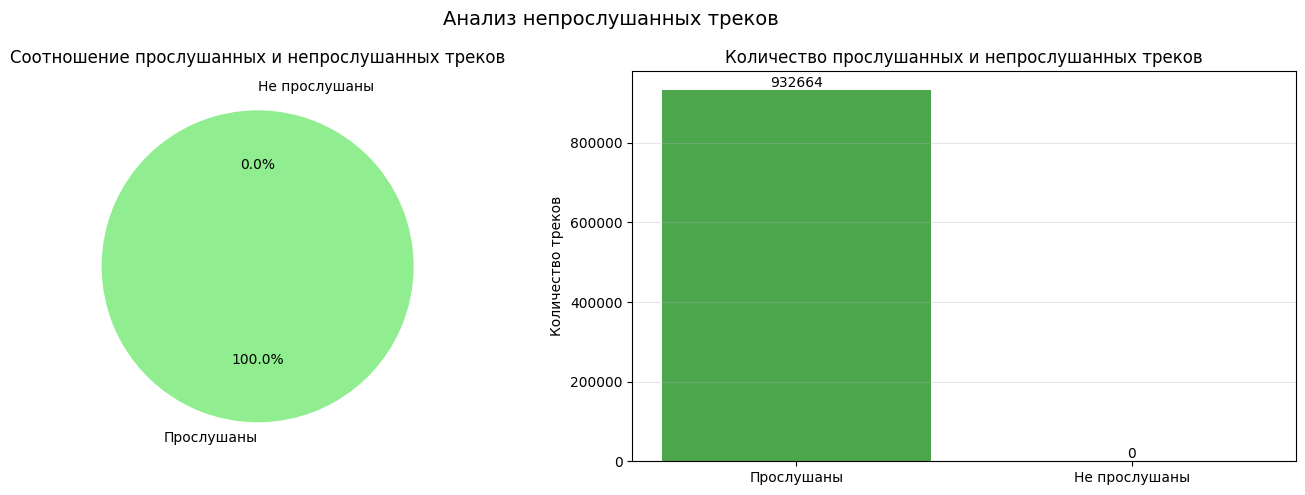

СТАТИСТИКА ПО НЕПРОСЛУШАННЫМ ТРЕКАМ
Всего треков в каталоге: 932664
Прослушанных треков: 932664
НЕПРОСЛУШАННЫХ треков: 0
Процент непрослушанных: 0.00%


In [43]:
all_tracks = set(tracks['track_id'].unique())
played_tracks = set(interactions['track_id'].unique())
unplayed_tracks = all_tracks - played_tracks

total_tracks = len(all_tracks)
played_count = len(played_tracks)
unplayed_count = len(unplayed_tracks)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Круговая диаграмма
labels = ['Прослушаны', 'Не прослушаны']
sizes = [played_count, unplayed_count]
colors = ['lightgreen', 'lightcoral']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[0].set_title('Соотношение прослушанных и непрослушанных треков')

# 2. Столбчатая диаграмма
bars = axes[1].bar(['Прослушаны', 'Не прослушаны'], [played_count, unplayed_count], 
                   color=['green', 'red'], alpha=0.7)
axes[1].set_ylabel('Количество треков')
axes[1].set_title('Количество прослушанных и непрослушанных треков')
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.suptitle('Анализ непрослушанных треков', fontsize=14)
plt.tight_layout()
plt.show()

# Статистика
print("="*60)
print("СТАТИСТИКА ПО НЕПРОСЛУШАННЫМ ТРЕКАМ")
print("="*60)

print(f"Всего треков в каталоге: {total_tracks}")
print(f"Прослушанных треков: {played_count}")
print(f"НЕПРОСЛУШАННЫХ треков: {unplayed_count}")
print(f"Процент непрослушанных: {unplayed_count/total_tracks*100:.2f}%")

del all_tracks, played_tracks, unplayed_tracks
del labels, sizes, colors, bars, fig, axes


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [47]:
import os
# Данные были ощищены на 1 этапе
items = tracks
events = interactions
os.makedirs(exist_ok=True, name='recsys/data')
items.to_parquet("recsys/data/items.parquet")
events.to_parquet("recsys/data/events.parquet")


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [50]:
import boto3
from botocore.exceptions import ClientError
from dotenv import load_dotenv

load_dotenv()

AWS_ACCESS_KEY_ID = os.environ.get('AWS_ACCESS_KEY_ID')
AWS_SECRET_ACCESS_KEY = os.environ.get('AWS_SECRET_ACCESS_KEY')
BUCKET_NAME = os.environ.get('BUCKET_NAME')

try:
    s3_client = boto3.client(
        's3',
        endpoint_url='https://storage.yandexcloud.net',
        aws_access_key_id=AWS_ACCESS_KEY_ID,
        aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    )
    
    s3_client.upload_file(
        "recsys/data/items.parquet",
        BUCKET_NAME,
        "recsys/data/items.parquet"
    )
    
    s3_client.upload_file(
        "recsys/data/events.parquet",
        BUCKET_NAME,
        "recsys/data/events.parquet"
    )
    
    
except ClientError as e:
    print(f"Ошибка при загрузке в S3: {e}")
    
except NameError as e:
    print(f"Ошибка: {e}")


del items, events


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [ ]:
# следует перезапустить kernel и продолжить с этапа 3
import gc

def clear_memory():
    """Очищает память от временных переменных"""
    
    temp_vars = [
        'indices_to_drop', 'check_object_ids', 'no_genre_ids', 
        'album_ids', 'artist_ids', 'genre_id', 'mask',
        
        'user_counts', 'track_popularity', 'top_20',
        'genres_dict', 'tracks_exploded', 'interactions_with_genres',
        'genre_popularity', 'top_10', 'top_5', 'other_sum', 'pie_data',
        'total_plays', 'top_1', 'top_3', 'data', 'stats',
        'all_tracks', 'played_tracks', 'unplayed_tracks',
        'labels', 'sizes', 'colors', 'bars',
    
        'fig', 'axes',
        
        'items', 'events',
        
        's3_client', 'AWS_ACCESS_KEY_ID', 'AWS_SECRET_ACCESS_KEY', 'BUCKET_NAME'
    ]
    
    deleted_count = 0
    for var in temp_vars:
        if var in globals():
            del globals()[var]
            deleted_count += 1
    
    gc.collect()
    
    
    important_vars = ['tracks', 'catalog_names', 'interactions', 'events', 'items']
    for var in important_vars:
        if var in globals():
            del globals()[var]

clear_memory()

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [2]:
import pandas as pd

# Из-за нехватки ресурсов и очень долгого исполнения кода уменьшаю датасет
# def get_decreased_dataset():
#     items = pd.read_parquet("./recsys/data/items.parquet")
#     events = pd.read_parquet("./recsys/data/events.parquet")
#     #catalog_names = pd.read_parquet("./catalog_names.parquet")

#     rows_to_drop = items.index[items.index % 2 == 1]
#     items_filtered = items.drop(rows_to_drop)
#     events_filtered = events.loc[events['track_id'].isin(items_filtered['track_id'])]
#     return (items_filtered, events_filtered)

items = pd.read_parquet("./recsys/data/items.parquet")
events = pd.read_parquet("./recsys/data/events.parquet")



In [2]:
events.shape

(214720738, 4)

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [3]:
train_split_date = pd.to_datetime("2022-12-16").date()
events_train = events.query("started_at < @train_split_date")
events_test = events.query("started_at >= @train_split_date")


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [4]:
# Популярность будем определять как кол-во ивентов (прослуш) по группам track_id (возможно, чтобы угодить большему проценту юзеров, можно брать по 20 самых прослуш треков в топ 5 жанрах и смешать их)

items_popularity = events_train.groupby(["track_id"], as_index=False).agg(popularity=("track_id", "count")).sort_values(by="popularity", ascending=False)
top_k = 100
top_k_items_popularity = items_popularity.head(top_k)
with pd.option_context('display.max_rows', top_k):
    display(top_k_items_popularity[['track_id', 'popularity']])

,track_id,popularity
8215,53404,110026
451664,33311009,101076
24433,178529,100866
478765,35505245,95523
341295,24692821,84153
83809,795836,83749
181264,6705392,80608
443347,32947997,80243
5869,37384,79512
607541,45499814,78564


In [ ]:
top_k_items_popularity.to_parquet('./recsys/recommendations/top_popular.parquet')

# Персональные

Рассчитаем персональные рекомендации.

In [ ]:
from implicit.als import AlternatingLeastSquares
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

item_id_encoder = LabelEncoder().fit(items['track_id'].unique())
items['track_id_enc'] = item_id_encoder.transform(items['track_id'])

events_train['track_id_enc'] = item_id_encoder.transform(events_train['track_id'])
events_test['track_id_enc'] = item_id_encoder.transform(events_test['track_id'])

user_id_encoder = LabelEncoder().fit(events['user_id'].unique())
events_train['user_id_enc'] = user_id_encoder.transform(events_train['user_id'])
events_test['user_id_enc'] = user_id_encoder.transform(events_test['user_id'])

user_item_matrix_train = csr_matrix((np.ones(len(events_train)), (events_train['user_id_enc'], events_train['track_id_enc'])), dtype=np.int8)

In [6]:
als_model = AlternatingLeastSquares(factors=50, iterations=10, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train)

/Users/viktar.karaneuski/Desktop/ml-yandex/mle-sprint-4/env_recsys_start/lib/python3.11/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [05:27<00:00, 32.76s/it]


In [7]:
user_ids_encoded = range(len(user_id_encoder.classes_))

als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, N=100)



In [8]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": item_ids_enc.tolist(), 
    "score": als_scores.tolist()})
als_recommendations = als_recommendations.explode(["item_id_enc", "score"], ignore_index=True)

als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype("int")
als_recommendations["score"] = als_recommendations["score"].astype("float")

# получаем изначальные идентификаторы
als_recommendations["user_id"] = user_id_encoder.inverse_transform(als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_id_encoder.inverse_transform(als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(columns=["user_id_enc", "item_id_enc"])

In [9]:
als_recommendations.sort_values(by='score', ascending=False)

,score,user_id,item_id
105311200,3.444912,1055078,18860
80010100,3.355421,801589,51241318
29842900,3.273762,298960,9060176
49471500,3.183874,495614,178529
8446100,3.164331,84603,18385776
...,...,...,...
117400765,0.000000,1176175,382
117400766,0.000000,1176175,379
104556700,0.000000,1047510,978
104556701,0.000000,1047510,977


In [ ]:
als_recommendations.to_parquet('./recsys/recommendations/personal_als.parquet')

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [11]:
train_item_ids_enc = events_train['track_id_enc'].unique()

max_similar_items = 10
similar_items = als_model.similar_items(train_item_ids_enc, N=max_similar_items+1)

sim_item_item_ids_enc = similar_items[0]
sim_item_scores = similar_items[1]

similar_items = pd.DataFrame({
    "item_id_enc": train_item_ids_enc,
    "sim_item_id_enc": sim_item_item_ids_enc.tolist(), 
    "score": sim_item_scores.tolist() })
similar_items = similar_items.explode(["sim_item_id_enc", "score"], ignore_index=True)

similar_items["sim_item_id_enc"] = similar_items['sim_item_id_enc'].astype("int")
similar_items["score"] = similar_items["score"].astype("float")

similar_items["item_id_1"] = item_id_encoder.inverse_transform(similar_items['item_id_enc'])
similar_items["item_id_2"] = item_id_encoder.inverse_transform(similar_items['sim_item_id_enc'])
similar_items = similar_items.drop(columns=["item_id_enc", "sim_item_id_enc"])

# убираем пары с одинаковыми объектами
similar_items = similar_items.query("item_id_1 != item_id_2")

In [ ]:
similar_items.to_parquet('./recsys/recommendations/similar.parquet')
#Перегружаем ядро, чтобы освободить ресурсы, загружаем заново данные items и events

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [3]:
print('max date', events_test['started_at'].max(), 'min date', events_test['started_at'].min())
split_date_for_labels = pd.to_datetime("2022-12-24")
events_labels = events_test[events_test['started_at'] < split_date_for_labels].copy()
events_test_2 = events_test[events_test['started_at'] >= split_date_for_labels].copy()


max date 2022-12-31 00:00:00 min date 2022-12-16 00:00:00


In [4]:
# Признак по треку - популярность, считаем как кол-во прослушиваний
def get_tracks_popularity(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby('track_id', as_index=False).agg(popularity=('track_id', 'count')).rename(columns={'track_id': 'item_id'})

# средняя доля прослушивания трека, среди доли прослушиваний трека пользователями
def get_user_track_listening_stats(df: pd.DataFrame) -> pd.DataFrame:
    user_all_listening = df.groupby(by='user_id', as_index=False).agg(all_listening_count=('user_id', 'count'))
    user_track_listening = df.groupby(by=['user_id', 'track_id'], as_index=False).agg(listening=('track_id', 'count'))
    user_track_stats = pd.merge(user_track_listening, user_all_listening, how='inner')
    user_track_stats['listening_percent'] = user_track_stats['listening'] / user_track_stats['all_listening_count']
    return user_track_stats.rename(columns={'track_id': 'item_id'}).groupby('item_id', as_index=False).agg(listening_percent=('listening_percent', 'mean'))

# Длительность истории пользователя
def get_user_history_len(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby(by='user_id', as_index=False).agg(listening_years=("started_at", lambda x: (x.max()-x.min()).days/365.25))



In [ ]:
events_labels['target'] = 1

track_popularity = get_tracks_popularity(events_train)[['item_id', 'popularity']]
user_track_listening_stats = get_user_track_listening_stats(events_train)[['item_id', 'listening_percent']]
user_history_len = get_user_history_len(events_train)[['user_id', 'listening_years']]

als_recommendations = pd.read_parquet('./recsys/recommendations/personal_als.parquet')

candidates = als_recommendations.merge((events_labels[['user_id', 'track_id', 'target']]).rename(columns={'track_id': 'item_id'}), how='left', on=['user_id', 'item_id'])
candidates['target'] = candidates['target'].fillna(0).astype('int')

candidates = candidates.merge(track_popularity, how='left', on=['item_id'])
candidates = candidates.merge(user_track_listening_stats, how='left', on=['item_id'])
candidates = candidates.merge(user_history_len, how='left', on=['user_id'])

del track_popularity, user_track_listening_stats, user_history_len


In [8]:
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)
negatives_per_user = 4
candidates_for_train = pd.concat([
    candidates_to_sample.query("target == 1"),
    candidates_to_sample.query("target == 0") \
        .groupby("user_id") \
        .apply(lambda x: x.sample(negatives_per_user, random_state=0))
    ])

In [10]:
candidates_for_train

,score,user_id,item_id,target,popularity,listening_percent,listening_years
1013,0.128073,10,45499814,1,78564,0.014818,0.213552
1025,0.112483,10,49125069,1,42845,0.016675,0.213552
1216,0.351029,12,31746480,1,33666,0.012223,0.646133
1534,0.016760,15,19606944,1,27988,0.007680,0.000000
1558,0.014943,15,17198356,1,34603,0.009245,0.000000
...,...,...,...,...,...,...,...
"(1374578, 137203755)",0.058715,1374578,39845787,0,20639,0.010740,0.410678
"(1374582, 137204102)",0.212863,1374582,69459326,0,29367,0.009247,0.104038
"(1374582, 137204133)",0.128276,1374582,35505245,0,95523,0.014315,0.104038
"(1374582, 137204160)",0.105939,1374582,59735856,0,16377,0.009199,0.104038


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [11]:
from catboost import CatBoostClassifier, Pool

features = ['score', 'popularity', 'listening_percent', 'listening_years']
target = 'target'

train_data = Pool(
    data=candidates_for_train[features], 
    label=candidates_for_train[target])

cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100,
    random_seed=0
)

cb_model.fit(train_data)

0:	learn: 0.6763754	total: 85.7ms	remaining: 1m 25s
100:	learn: 0.5713324	total: 2.16s	remaining: 19.2s
200:	learn: 0.5560031	total: 4.26s	remaining: 16.9s
300:	learn: 0.5463948	total: 6.4s	remaining: 14.9s
400:	learn: 0.5391609	total: 8.54s	remaining: 12.7s
500:	learn: 0.5333428	total: 10.7s	remaining: 10.7s
600:	learn: 0.5279146	total: 12.8s	remaining: 8.53s
700:	learn: 0.5239390	total: 15s	remaining: 6.38s
800:	learn: 0.5204886	total: 17.1s	remaining: 4.25s
900:	learn: 0.5175067	total: 19.2s	remaining: 2.11s
999:	learn: 0.5144485	total: 21.3s	remaining: 0us


In [13]:
# Не генерировал новые рекомендации на основе уже train + labels
candidates_to_rank = als_recommendations[als_recommendations["user_id"].isin(events_test_2["user_id"].drop_duplicates())]

track_popularity = get_tracks_popularity(events_train)[['item_id', 'popularity']]
user_track_listening_stats = get_user_track_listening_stats(events_train)[['item_id', 'listening_percent']]
user_history_len = get_user_history_len(events_train)[['user_id', 'listening_years']]

candidates_to_rank = candidates_to_rank.merge(track_popularity, how='left', on=['item_id'])
candidates_to_rank = candidates_to_rank.merge(user_track_listening_stats, how='left', on=['item_id'])
candidates_to_rank = candidates_to_rank.merge(user_history_len, how='left', on=['user_id'])

del track_popularity, user_track_listening_stats, user_history_len


In [15]:
inference_data = Pool(data=candidates_to_rank[features])
predictions = cb_model.predict_proba(inference_data)

candidates_to_rank["cb_score"] = predictions[:, 1]

candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1

max_recommendations_per_user = 100
final_recommendations = candidates_to_rank.query("rank <= @max_recommendations_per_user")

In [ ]:
final_recommendations.to_parquet('./recsys/recommendations/recommendations.parquet')

In [ ]:
# Перегружаю ядро, чтоб освободить ресурсы

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [47]:
import pandas as pd

def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None):

    """
    размечает пары <user_id, item_id> для общего множества пользователей признаками
    - gt (ground truth)
    - pr (prediction)
    top_k: расчёт ведётся только для top k-рекомендаций
    """

    events_test["gt"] = True
    common_users = set(events_test["user_id"]) & set(recs["user_id"])
    print(f"Common users: {len(common_users)}")
    
    events_for_common_users = events_test[events_test["user_id"].isin(common_users)].copy()
    recs_for_common_users = recs[recs["user_id"].isin(common_users)].copy()

    recs_for_common_users = recs_for_common_users.sort_values(["user_id", "score"], ascending=[True, False])

    # оставляет только те item_id, которые были в events_train, 
    # т. к. модель не имела никакой возможности давать рекомендации для новых айтемов
    events_for_common_users = events_for_common_users[events_for_common_users["item_id"].isin(events_train["item_id"].unique())]

    if top_k is not None:
        recs_for_common_users = recs_for_common_users.groupby("user_id").head(top_k)
    
    events_recs_common = events_for_common_users[["user_id", "item_id", "gt"]].merge(
        recs_for_common_users[["user_id", "item_id", "score"]], 
        on=["user_id", "item_id"], how="outer")    

    events_recs_common["gt"] = events_recs_common["gt"].fillna(False)
    events_recs_common["pr"] = ~events_recs_common["score"].isnull()
    
    events_recs_common["tp"] = events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fp"] = ~events_recs_common["gt"] & events_recs_common["pr"]
    events_recs_common["fn"] = events_recs_common["gt"] & ~events_recs_common["pr"]

    return events_recs_common

def compute_recall_precision_metrics(events_recs_for_binary_metric):
    
    groupper = events_recs_for_binary_metric.groupby("user_id")

    # precision = tp / (tp + fp)
    precision = groupper["tp"].sum()/(groupper["tp"].sum()+groupper["fp"].sum())
    precision = precision.fillna(0).mean()
    
    # recall = tp / (tp + fn)
    recall = groupper["tp"].sum()/(groupper["tp"].sum()+groupper["fn"].sum())
    recall = recall.fillna(0).mean()

    return precision, recall

def calculate_novelty(events_train, recommendations_df, k=5):
    """
    Расчет novelty@k
    """
    # Размечаем рекомендации
    events_train["listen"] = True
    recs = recommendations_df.merge(
        events_train[["listen", "user_id", "item_id"]], 
        on=["user_id", "item_id"], 
        how="left"
    )
    recs["listen"] = recs["listen"].fillna(False).astype("bool")
    
    # Сортируем и берем top-k
    recs = recs.sort_values(by=["user_id", "score"], ascending=[True, False])
    recs["rank"] = recs.groupby("user_id").cumcount() + 1
    recs_topk = recs[recs["rank"] <= k]
    
    # Novelty = 1 - среднее listen по пользователям
    novelty_by_user = 1 - recs_topk.groupby("user_id")["listen"].mean()
    
    return novelty_by_user.mean()


def calculate_coverage(events_train, recommendations_df, k=5):
    """
    Расчет coverage@k
    """
    # Сортируем и берем top-k
    recs = recommendations_df.sort_values(by=["user_id", "score"], ascending=[True, False])
    recs["rank"] = recs.groupby("user_id").cumcount() + 1
    recs_topk = recs[recs["rank"] <= k]
    
    # Coverage = уникальные рекомендованные товары / все товары в train
    all_train_items = set(events_train['item_id'].unique())
    recommended_items = set(recs_topk['item_id'].unique())
    
    return len(recommended_items) / len(all_train_items)

In [23]:
events = pd.read_parquet("./recsys/data/events.parquet")

train_split_date = pd.to_datetime("2022-12-16").date()
events_train = events.query("started_at < @train_split_date")
events_test = events.query("started_at >= @train_split_date")


In [34]:
events_train = events_train.rename(columns={'track_id': 'item_id'})
events_test = events_test.rename(columns={'track_id': 'item_id'})

In [73]:
top_popular_recs = pd.read_parquet('./recsys/recommendations/top_popular.parquet').rename(columns={'track_id': 'item_id'})

In [78]:

top_recs_with_users = events_test[['user_id', 'item_id']].merge(top_popular_recs, how='left', on=['item_id'])
# cold_user_items_no_popularity_idx = cold_users_events_with_recs["popularity"].isnull()
# cold_user_recs = cold_users_events_with_recs[~cold_user_items_no_popularity_idx]

In [79]:
prepared_top_to_binary_metrics = process_events_recs_for_binary_metrics(events_train, events_test, top_recs_with_users.rename(columns={'popularity': 'score'}))
precision, recall = compute_recall_precision_metrics(prepared_top_to_binary_metrics)
print(f"top precision {precision:.3f} top recall {recall:.3f}")
print(f"top novelty@5 {calculate_novelty(events_train, top_recs_with_users.rename(columns={'popularity': 'score'})):.3f}  top coverage@5 {calculate_coverage(events_train, top_recs_with_users.rename(columns={'popularity': 'score'})):.3f}")

Common users: 778789
top precision 0.212 top recall 0.034
top novelty@5 1.000  top coverage@5 0.336


In [52]:
# Персональные
als_recs = pd.read_parquet('./recsys/recommendations/personal_als.parquet')

In [ ]:
prepared_top_to_binary_metrics = process_events_recs_for_binary_metrics(events_train, events_test, als_recs)
precision, recall = compute_recall_precision_metrics(prepared_top_to_binary_metrics)
novelty = calculate_novelty(events_train, als_recs)
coverage = calculate_coverage(events_train, als_recs)


Common users: 778789
Метрики als recs: precision {precision:.3f} recall {recall:.3f} novelty@5 {novelty:.3f} coverage@5 {coverage:.3f}


In [55]:
print(f"Метрики als recs: precision {precision:.3f} recall {recall:.3f} novelty@5 {novelty:.3f} coverage@5 {coverage:.3f}")

Метрики als recs: precision 0.007 recall 0.085 novelty@5 0.629 coverage@5 0.002


In [58]:
final_recs = pd.read_parquet('./recsys/recommendations/recommendations.parquet')
final_recs = final_recs[['user_id', 'item_id', 'cb_score']].rename(columns={'cb_score': 'score'})

In [60]:
prepared_top_to_binary_metrics = process_events_recs_for_binary_metrics(events_train, events_test, final_recs)
precision, recall = compute_recall_precision_metrics(prepared_top_to_binary_metrics)
novelty = calculate_novelty(events_train, final_recs)
coverage = calculate_coverage(events_train, final_recs)

Common users: 567159


In [61]:
print(f"Метрики для итоговых recs: precision {precision:.3f} recall {recall:.3f} novelty@5 {novelty:.3f} coverage@5 {coverage:.3f}")

Метрики для итоговых recs: precision 0.008 recall 0.084 novelty@5 0.844 coverage@5 0.007


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.